### Checklist for submission

It is extremely important to make sure that:

1. Everything runs as expected (no bugs when running cells);
2. The output from each cell corresponds to its code (don't change any cell's contents without rerunning it afterwards);
3. All outputs are present (don't delete any of the outputs);
4. Fill in all the places that say `# YOUR CODE HERE`, or "**Your answer:** (fill in here)".
5. Never copy/paste any notebook cells. Inserting new cells is allowed, but it should not be necessary.
6. The notebook contains some hidden metadata which is important during our grading process. **Make sure not to corrupt any of this metadata!** The metadata may for example be corrupted if you copy/paste any notebook cells, or if you perform an unsuccessful git merge / git pull. It may also be pruned completely if using Google Colab, so watch out for this. Searching for "nbgrader" when opening the notebook in a text editor should take you to the important metadata entries.
7. Although we will try our very best to avoid this, it may happen that bugs are found after an assignment is released, and that we will push an updated version of the assignment to GitHub. If this happens, it is important that you update to the new version, while making sure the notebook metadata is properly updated as well. The safest way to make sure nothing gets messed up is to start from scratch on a clean updated version of the notebook, copy/pasting your code from the cells of the previous version into the cells of the new version.
8. If you need to have multiple parallel versions of this notebook, make sure not to move them to another directory.
9. Although not forced to work exclusively in the course `conda` environment, you need to make sure that the notebook will run in that environment, i.e. that you have not added any additional dependencies.

Failing to meet any of these requirements might lead to a request for resubmission if the errors are serious enough.

We advise you to perform the following steps before submission to ensure that requirements 1, 2, and 3 are always met: **Restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All). This might require a bit of time, so plan ahead for this (and possibly use a cloud GPU in HA3 and HA4 for this step). Finally press the "Save and Checkout" button before handing in, to make sure that all your changes are saved to this .ipynb file.

### Fill in name of notebook file
This might seem silly, but the version check below needs to know the filename of the current notebook, which is not trivial to find out programmatically.

You might want to have several parallel versions of the notebook, and it is fine to rename the notebook as long as it stays in the same directory. **However**, if you do rename it, you also need to update its own filename below:

In [1]:
nb_fname = "HA2.ipynb"

### Fill in group number and member names:

In [2]:
NAME1 = ""
NAME2 = ""
GROUP = ""

### Check Python version

In [3]:
from platform import python_version_tuple

assert (
    python_version_tuple()[:2] == ("3", "11")
), "You are not running Python 3.11. Make sure to run Python through the course Conda environment."

### Check that notebook server has access to all required resources, and that notebook has not moved

In [4]:
import os

nb_dirname = os.path.abspath("")
assignment_name = os.path.basename(nb_dirname)
assert assignment_name in [
    "HA1",
    "HA2",
    "HA3",
    "HA4",
], "[ERROR] The notebook appears to have been moved from its original directory"

### Verify correct nb_fname

In [5]:
from IPython.display import HTML, display

try:
    display(
        HTML(
            r'<script>if("{nb_fname}" != IPython.notebook.notebook_name) {{ alert("You have filled in nb_fname = \"{nb_fname}\", but this does not seem to match the notebook filename \"" + IPython.notebook.notebook_name + "\"."); }}</script>'.format(
                nb_fname=nb_fname
            )
        )
    )
except NameError:
    assert False, "Make sure to fill in the nb_fname variable above!"

### Verify that your notebook is up-to-date and not corrupted in any way

In [6]:
import sys

sys.path.append("..")
from ha_utils import check_notebook_uptodate_and_not_corrupted

check_notebook_uptodate_and_not_corrupted(nb_dirname, nb_fname)

Failed to fetch the URL: http://raw.githubusercontent.com/dml-cth/deep-machine-learning/master/home-assignments/HA2/HA2-Part1.ipynb
[WARNING] Could not fetch reference notebook from GitHub repo. Are you offline?
[WARNING] Could not verify that current notebook is up-to-date and not corrupted


# HA2 - Catching Pokemon

![](https://upload.wikimedia.org/wikipedia/en/4/46/Pokemon_Go.png)

In this home assignment, you'll apply roughly the same principles we used when doing logistic regression on the Iris dataset in Computer Lab 1, but on a different and very interesting dataset. We'll use the [Predict'em All dataset from Kaggle](https://www.kaggle.com/semioniy/predictemall). To download the dataset you will need a Kaggle account. This dataset consists of roughly 293,000 [pokemon](http://www.pokemongo.com/) sightings (historical appearances of Pokemon in the Pokemon Go game), with geographical coordinates, time, weather, population density, distance to pokestops/gyms etc. as features. A comprehensive list of all the features is available at [the dataset's homepage](https://www.kaggle.com/semioniy/predictemall).

The context is simple: you are a Pokemon hunter, and there are only three Pokemon left for you to complete your collection. You'll do anything to capture them, including changing where you'll spend your next holidays! You know that some Pokemon only spawn in certain places of the world. Since you like machine learning so much, you figure it would be a great idea to train a classifier that, based on a location's longitude and latitude, can tell us which Pokemon is more likely to appear there.

The assignment is broken down into six steps.

1. Loading the data and extracting the desired subset of it
2. Visualization of the dataset
3. Preprocessing
4. Training
5. Evaluation
6. Exploration

Feel free to temporarily add cells wherever you see fit, and play around with this notebook as much as you want when developing the solutions. However, the solution you upload to Canvas must have the exact format shown here, with only the cells present here.

Don't restrict yourself only to what was taught so far. Some of the tasks might require you to search for new information. However, **be sure that you do the assignment using PyTorch** since we will be using it through the following assignments as well. [The Python docs](https://docs.python.org/3/), [PyTorch docs](https://pytorch.org/docs/stable/index.html), [stackoverflow](https://stackoverflow.com/), and Google are your friends!

**Hint:** Solving Computer Lab 1 (CL1) is a good way to get prepared for this assignment.

To pass this assignment, your solutions should pass all tests (`assert`-statements). Note that the tests shown to you are not exhaustive, and additional hidden tests exist for some of the tasks. Further, similar to HA1, this notebook contains some questions where we ask you to reflect upon some results. These questions will not be graded in detail, but we still expect you to answer them.

## 0. Imports

Import any necessary modules here.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


## 1. Loading and extracting subset

The first step consists of filtering the dataset by the three Pokémon you are interested at. 

Start by loading the `'300k.csv'` file using pandas. If you haven't downloaded it yet, either use [this link](https://www.kaggle.com/semioniy/predictemall) to do so (and place the file in the same folder as this notebook), or simply run the cell below. You might have to [create a new API token](https://www.kaggle.com/settings/account) before the commands work.

In [8]:
# The dataset is already downloaded into this folder as 300k.csv. The commands
# below only run if it is not there yet (they need a Kaggle API token).
import os

if not os.path.exists("300k.csv"):
    !kaggle datasets download -d semioniy/predictemall
    !unzip -u predictemall.zip
    !rm -rf predictemall.zip 300k_arff 300k.arff 300k_csv


In [9]:
df = pd.read_csv("300k.csv", low_memory=False)


In [10]:
assert df.shape == (
    296021,
    208,
), f"Dataframe has not the right shape. {df.shape} != (296021, 208)"
assert isinstance(df, pd.DataFrame), f"df is not a dataframe. Was {type(df)}"

Modify `df` to only have the columns `latitude`, `longitude`, and `class`.

In [11]:
df = df[["latitude", "longitude", "class"]]


In [12]:
assert len(df.columns) == 3, "There should be 3 columns"
assert len(df.shape) == 2, "The dataframe should be 2 dimensional"
assert df.shape == (296021, 3), "Wrong shape of the dataframe"
assert "latitude" in df.columns, "latitude column is missing"
assert "longitude" in df.columns, "longitude column is missing"
assert "class" in df.columns, "class column is missing"

Note that the `class` column specifies which pokemon it is. However, it only has the numerical id of the pokemon. For your convenience, we provide the dictionary `name_dict` to convert between ids and names (we'll do this soon).

In [13]:
from utils import name_dict

In [14]:
# example usage (you can index either by name or id)
print(name_dict["Gengar"])
print(name_dict[94])

94
Gengar


In [15]:
# for convenience, let's add a new column to the dataframe with the name of the pokemon
df["name"] = df["class"].apply(lambda x: name_dict[x])
print(df.head())

    latitude   longitude  class    name
0  20.525745  -97.460829     16  Pidgey
1  20.523695  -97.461167    133   Eevee
2  38.903590  -77.199780     16  Pidgey
3  47.665903 -122.312561     13  Weedle
4  47.666454 -122.311628    133   Eevee


We are only interested in three specific pokemon: Diglett, Seel, and Tauros.

<table style="width:100%">
  <tr>
    <th> <center>Diglett</center> </th>
    <th> <center>Seel</center> </th> 
    <th> <center>Tauros</center> </th>
  </tr>
  <tr>
    <td><img src=https://assets.pokemon.com/assets/cms2/img/pokedex/full/050_f2.png alt=Digglet></td>
    <td><img src=https://pokemon.gamepedia.com/media/pokemon.gamepedia.com/thumb/f/f1/Seel.png/200px-Seel.png?version=2c32fbe0af2d0da707e5dbcb40472fbf></td>
    <td><img src=https://www.pokemon.com/static-assets/content-assets/cms2/img/pokedex/full/128.png></td>
  </tr>
</table>



Filter the dataset to contain only these three types of pokemon and save it in the DataFrame `filtered_df`.

In [16]:
filtered_df = df[df["name"].isin(["Diglett", "Seel", "Tauros"])].copy()
print(
    f"We have {len(filtered_df)} instances of Diglett, Seel, and Tauros in the dataset."
)


We have 2083 instances of Diglett, Seel, and Tauros in the dataset.


In [17]:
assert len(np.unique(filtered_df["class"])) == 3, "There should be 3 unique classes."
assert filtered_df.shape == (
    2083,
    4,
), "The shape of the filtered dataframe is incorrect."

In an earlier cell, you could see that the dataset has 208 features per pokemon sighting (`df.shape == (296021, 208)`). Why do we only use the `longitude` and `latitude` features and not all the features? 

**Your answer:** Because the question we want to answer is *where* each Pokemon appears. Most of the other 205 features are either a direct consequence of the location (city, continent, geohash, cellId, distance to the nearest gym/pokestop, ...) or describe the conditions of one particular sighting (time of day, temperature, wind, pressure, ...). The location is the only feature that generalises to unseen places and to future sightings, and it is the quantity we can control when we choose where to travel. Adding the remaining features would mostly let the model memorise which *specific* sightings are in the training set, and several of them (population density, pokestop density) are really proxies for *where players are*, which would make the classifier reproduce the sampling bias of the data rather than the true spawning behaviour. Keeping the input at two dimensions keeps the problem interpretable and matches the final goal (predicting a place on a map).

## 2. Visualization of the dataset

The second step consists of visualizing the dataset. This will help you understand the distribution of the features and get an idea of how hard the task will be.

Plot a bar chart of the number of occurrences of each class.

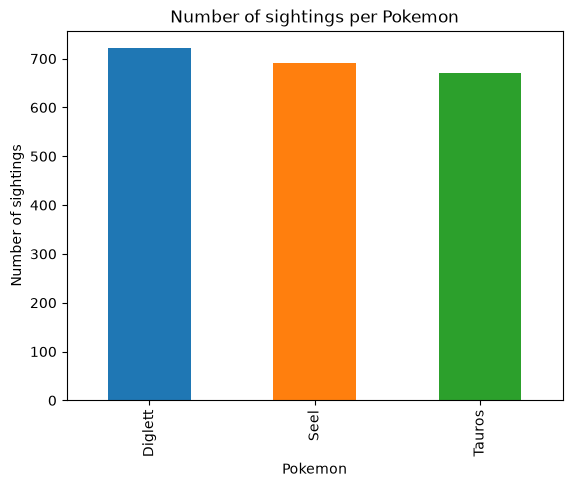

In [18]:
class_counts = filtered_df["name"].value_counts()
class_counts.plot(kind="bar", color=["tab:blue", "tab:orange", "tab:green"])
plt.xlabel("Pokemon")
plt.ylabel("Number of sightings")
plt.title("Number of sightings per Pokemon")
plt.show()


Is the dataset balanced? Why/why not? Why is this important?

**Your answer:** The dataset is fairly balanced: Diglett 721 (34.6%), Seel 692 (33.2%) and Tauros 670 (32.2%) of the 2083 sightings — no class dominates the others. The reason is that this subset is simply *all* recorded sightings of these three Pokemon in the source data, not a sample designed with some target class balance, and these particular Pokemon happen to be sighted with comparable frequency.

Balance matters because accuracy is only a meaningful summary when the classes are of comparable size: with a heavily imbalanced dataset, a model could reach high accuracy by always predicting the majority class, and the cross-entropy loss would be dominated by that class. Here the classes are similar in size, so accuracy is a fair metric and the network is not strongly biased towards any single class (we still inspect the confusion matrix to see where errors concentrate).

Plot a scatter plot where the first dimension is longitude, the second is latitude, and each point is a Pokemon. Further, the color of each point should represent which Pokemon it is. Lastly, the marker at each point should be an `'x'`. Make sure to label each axis.

Hints:

- The `scatter` method from `matplotlib` accepts an argument called `c`.
- The `scatter` method also accepts an argument called `marker`.

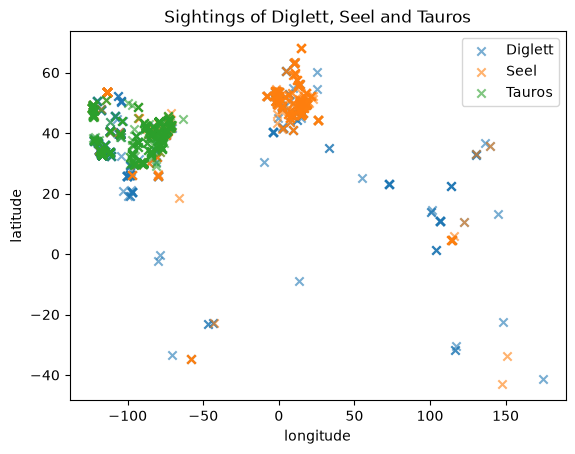

In [19]:
for pokemon, color in zip(
    ["Diglett", "Seel", "Tauros"], ["tab:blue", "tab:orange", "tab:green"]
):
    subset = filtered_df[filtered_df["name"] == pokemon]
    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        c=color,
        marker="x",
        label=pokemon,
        alpha=0.6,
    )
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Sightings of Diglett, Seel and Tauros")
plt.legend()
plt.show()


Is there any other visualization you think would be useful? If so, insert them here.

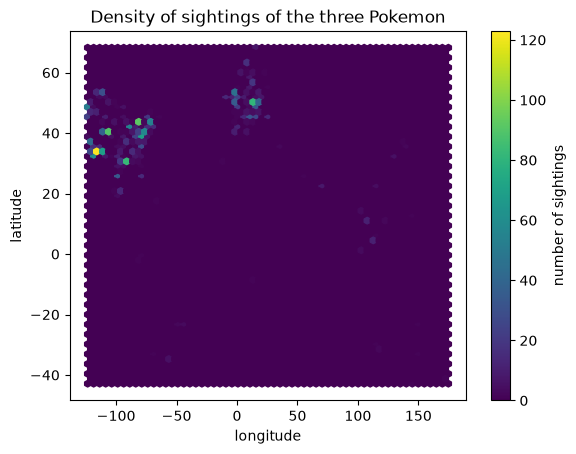

In [20]:
# A density (hexbin) view of the same data: it shows where the sightings are
# concentrated, which the scatter plot makes hard to judge for overlapping points.
plt.hexbin(
    filtered_df["longitude"], filtered_df["latitude"], gridsize=60, cmap="viridis"
)
plt.colorbar(label="number of sightings")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Density of sightings of the three Pokemon")
plt.show()


How hard do you think the problem is? Which classes can/cannot be easily separated?


**Your answer:** The task is moderately hard; the classes overlap heavily and cannot be separated by geography alone. Looking at the scatter plot and the per-class coordinate statistics, the three Pokemon have different *centres of mass* — Tauros is concentrated on the North American mainland (longitude −123 to −64, latitude 29 to 51), Diglett is spread much more widely (a strong cluster on the US East Coast plus a second cluster in Japan, longitude −123 to 175), and Seel is centred on Europe and the North Atlantic (mean longitude ≈ −24). Tauros is therefore the easiest class to recognise, because it almost never leaves the US mainland; Seel and Diglett overlap with each other (and with Tauros) over the US East Coast and Europe.

Since none of the classes is confined to a region that the others never visit, a perfect separation is impossible. The best we can hope for is a model that learns the (irregular, non-convex) regions where each class is most likely, and accepts a considerable number of errors in the overlap zones.

Which accuracy do you expect to achieve?

**Your answer:** Given the overlap described above, I expect something in the 70-80% range: high enough to be clearly better than the majority-class baseline (which would be only ~35%), but far from perfect because the classes genuinely overlap and the same location can realistically host all three Pokemon. A linear classifier should not be much better than chance-plus-a-bit (we will see ~47%), so a non-linear model with a few hundred hidden units is needed to shape the decision regions around the clusters.

## 3. Preprocessing

The third step consists of processing the data before training, such as dividing the dataset into training, validation, and test sets. Some tranformations can also be applied to the dataset in order to improve the performance of the network. We will use some PyTorch utilities to help us with this task.

Start by creating the input and output vectors, `x` and `y`. The input should be latitude and longitude, and the output should be the class of the pokemon. Note that you cannot use the class names directly, as they are strings. You need to introduce some mapping to convert them to integers (0, 1, and 2) or one-hot vectors.

In [21]:
# Map the class names to consecutive integer labels 0, 1, 2
class_to_idx = {"Diglett": 0, "Seel": 1, "Tauros": 2}

# Input features: latitude and longitude (columns of x: [latitude, longitude])
x = filtered_df[["latitude", "longitude"]].to_numpy(dtype=np.float32)
# Labels: label encoded (0, 1, 2)
y = filtered_df["name"].map(class_to_idx).to_numpy()

print(f"Shape of input data: {x.shape}")
print(f"Shape of labels: {y.shape}")


Shape of input data: (2083, 2)
Shape of labels: (2083,)


In [22]:
assert isinstance(x, np.ndarray), "x should be a numpy array"
assert isinstance(y, np.ndarray), "y should be a numpy array"

assert x.shape[0] == y.shape[0], "x and y should have the same number of samples"
assert x.shape[-1] == 2, "x should have 2 features"
assert x.dtype == np.float32, "x should be of type float32"
if y.shape[-1] == 3:  # one-hot encoded
    assert y.max() == 1, "one-hot encoded y, at least one entry should be 1"
    assert y.min() == 0, "one-hot encoded y, at least one entry should be 0"
    assert y.sum(axis=1).all() == 1
else:  # label encoded
    assert y.max() == 2, "label encoded y, should have a max value of 2"
    assert y.min() == 0, "label encoded y, should have a min value of 0"

Separate your data into training (55%), validation (25%) and test sets (20%) and save them as `dataset_train`, `dataset_val`, `dataset_test`. If you wish to apply any transformation to the dataset, do it here as well. 

Further, create a class, PokemonDataset, inheriting from PyTorch [`Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and use this for storing the data. In other words, `dataset_train`, `dataset_val`, `dataset_test` should have type PokemonDataset. You will need to implement a `__getitem__`, `__len__` and `__init__` method. Although perhaps a bit overkill for this assignment, it is a good practice for handling datasets in PyTorch.

Last, instantiate a [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for each dataset, i.e., `loader_train`, `loader_val`, `loader_test`. This will fetch samples from the datasets and combine them into batches. Remember to select a suitable batch size.

In [23]:
class PokemonDataset(Dataset):
    """PyTorch dataset holding the pokemon coordinates and their labels."""

    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

    def __len__(self):
        return len(self.x)


# Shuffle the data and split it into 55% train, 25% validation and 20% test
rng = np.random.default_rng(42)
perm = rng.permutation(len(x))
n_train = int(0.55 * len(x))
n_val = int(0.25 * len(x))
idx_train = perm[:n_train]
idx_val = perm[n_train : n_train + n_val]
idx_test = perm[n_train + n_val :]

# Standardize the features (zero mean, unit variance). The statistics are
# computed on the training set only, to avoid leaking information from the
# validation/test sets. This normalization makes training much easier.
x_mean = x[idx_train].mean(axis=0)
x_std = x[idx_train].std(axis=0)
x_norm = (x - x_mean) / x_std

dataset_train = PokemonDataset(x_norm[idx_train], y[idx_train])
dataset_val = PokemonDataset(x_norm[idx_val], y[idx_val])
dataset_test = PokemonDataset(x_norm[idx_test], y[idx_test])

batch_size = 512
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size)
loader_test = DataLoader(dataset_test, batch_size=batch_size)


In [24]:
assert isinstance(
    dataset_train, PokemonDataset
), "dataset_train should be an instance of PokemonDataset"
assert isinstance(
    dataset_val, PokemonDataset
), "dataset_val should be an instance of PokemonDataset"
assert isinstance(
    dataset_test, PokemonDataset
), "dataset_test should be an instance of PokemonDataset"

assert (
    abs(len(dataset_train) / len(x) - 0.55) < 0.01
), "dataset_train has the wrong length, should be 55% of the data"
assert (
    abs(len(dataset_val) / len(x) - 0.25) < 0.01
), "dataset_val has the wrong length, should be 25% of the data"
assert (
    abs(len(dataset_test) / len(x) - 0.20) < 0.01
), "dataset_test has the wrong length, should be 20% of the data"

assert isinstance(
    loader_train, DataLoader
), "loader_train should be an instance of DataLoader"
assert isinstance(
    loader_val, DataLoader
), "loader_val should be an instance of DataLoader"
assert isinstance(
    loader_test, DataLoader
), "loader_test should be an instance of DataLoader"

assert len(loader_train), "loader_train should have a length"
assert len(loader_val), "loader_val should have a length"
assert len(loader_test), "loader_test should have a length"

## 4. Training

The fourth step is where you will choose the architecture of your network (number of hidden layers, activation functions, etc.), optimizer, loss function and then train the network. 

Start by implementing a training loop, and a helper function to calculate the accuracy. The training loop should calculate the loss and accuracy for both the training and validation set and print it with some regular interval (each epoch, or every few epochs, for instance). It can also be helpful to plot the loss and accuracy for both the training and validation set, either in the training loop, or after it has finished (i.e., you have to store the values during training and return them).

We have prepared the `train_model` function with the arguments you need, but you have access to *args and **kwargs if you want to pass additional arguments to the function.

In [25]:
from typing import Callable, Union

import torch
import torch.nn as nn
import torch.utils


def accuracy(y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Compute the accuracy of the model.

    Args:
    y_hat: torch.Tensor: The model predictions (probability per class), shape: [batch_size, num_classes]
    y: torch.Tensor: The true labels, shape: [batch_size]

    Returns:
    torch.Tensor: The accuracy of the model
    """
    predictions = y_hat.argmax(dim=1)
    acc = (predictions == y).float().mean()
    return acc


def train_model(
    model: nn.Module,
    optimizer: torch.optim,
    loss_fn: Union[Callable, nn.Module],
    num_epochs: int,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader,
    device: Union[str, torch.device],
    *args,
    **kwargs,
):
    """
    Train the model.

    Args:
    model: nn.Module: The neural network model
    optimizer: torch.optim: The optimizer used to update the model parameters
    loss_fn: Union[Callable, nn.Module]: The loss function used to compute the loss
    num_epochs: int: The number of epochs to train the model
    train_dataloader: torch.utils.data.DataLoader: The training dataloader
    val_dataloader: torch.utils.data.DataLoader: The validation dataloader
    device: Union[str, torch.device]: The device to run the training on
    *args: Additional arguments to pass to the train function
    **kwargs: Additional keyword arguments to pass to the train function

    """
    print_every = kwargs.get("print_every", max(1, num_epochs // 10))
    model.to(device)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    def run_epoch(dataloader, train: bool):
        running_loss, running_correct, n_samples = 0.0, 0, 0
        model.train(train)
        with torch.set_grad_enabled(train):
            for x_batch, y_batch in dataloader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                if train:
                    optimizer.zero_grad()
                logits = model(x_batch)
                loss = loss_fn(logits, y_batch)
                if train:
                    loss.backward()
                    optimizer.step()
                running_loss += loss.item() * y_batch.size(0)
                running_correct += (logits.argmax(dim=1) == y_batch).sum().item()
                n_samples += y_batch.size(0)
        return running_loss / n_samples, running_correct / n_samples

    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(train_dataloader, train=True)
        val_loss, val_acc = run_epoch(val_dataloader, train=False)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs} | "
                f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
                f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
            )

    return history


Next, we'll test that your training loop is correct. A [common sanity check in deep learning](https://karpathy.github.io/2019/04/25/recipe/) is to overfit to a small dataset, like a single batch of data. This ensures that shapes and devices are correctly set, and the network can learn/memorize the training data, which is a good starting point before training on the full dataset.

In [26]:
def test_train_loop():
    import torch.nn as nn
    import torch.optim as optim
    import torch.utils.data as data

    # init simple model, optimizer, loss_fn, dataloaders
    linear_model = nn.Linear(2, 3)
    optimizer = optim.SGD(linear_model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    testing_loader_train = data.DataLoader(
        data.TensorDataset(torch.randn(2, 2), torch.randint(0, 3, (2,)))
    )
    testing_loader_val = data.DataLoader(
        data.TensorDataset(torch.randn(2, 2), torch.randint(0, 3, (2,)))
    )

    # copy parameters to check for changes
    params_before_training = list(linear_model.parameters())
    params_before_training = [p.clone().to("cpu") for p in params_before_training]

    print("Testing training loop, CPU")
    train_model(
        model=linear_model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=100,
        train_dataloader=testing_loader_train,
        val_dataloader=testing_loader_val,
        device="cpu",
    )
    if torch.cuda.is_available():
        print("Testing training loop, CUDA")
        train_model(
            model=linear_model,
            optimizer=optimizer,
            loss_fn=loss_fn,
            num_epochs=100,
            train_dataloader=testing_loader_train,
            val_dataloader=testing_loader_val,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )

    params_after_training = list(linear_model.parameters())
    params_after_training = [p.clone().to("cpu") for p in params_after_training]
    for p_before, p_after in zip(params_before_training, params_after_training):
        assert torch.any(
            p_before != p_after
        ), "Model parameters did not change during training"

    # check that we could overfit a single example
    (x, y) = next(iter(testing_loader_train))
    x.to("cpu")
    y.to("cpu")
    linear_model.to("cpu")
    assert (
        linear_model(x).argmax().item() == y.item()
    ), "Model could not overfit a single example"


def test_accuracy():
    y_pred = torch.tensor([[0.1, 0.8, 0.1], [0.3, 0.4, 0.3], [0.1, 0.1, 0.8]])
    y_true = torch.tensor([1, 0, 2])
    acc = accuracy(y_pred, y_true)
    assert isinstance(acc, torch.Tensor), "Accuracy should be a torch.Tensor"
    assert torch.isclose(acc, torch.tensor(2 / 3)), f"Accuracy is {acc}, expected 2/3"


try:
    test_train_loop()
except Exception as e:
    print(e)
    assert False, "Training test failed, see error above"

test_accuracy()

Testing training loop, CPU
Epoch 1/100 | train loss: 1.6506, train acc: 0.0000 | val loss: 1.4326, val acc: 0.0000
Epoch 10/100 | train loss: 1.2750, train acc: 0.0000 | val loss: 1.3147, val acc: 0.0000
Epoch 20/100 | train loss: 0.9629, train acc: 0.5000 | val loss: 1.2269, val acc: 0.0000
Epoch 30/100 | train loss: 0.7415, train acc: 1.0000 | val loss: 1.1746, val acc: 0.5000
Epoch 40/100 | train loss: 0.5860, train acc: 1.0000 | val loss: 1.1470, val acc: 0.5000
Epoch 50/100 | train loss: 0.4757, train acc: 1.0000 | val loss: 1.1356, val acc: 0.5000
Epoch 60/100 | train loss: 0.3955, train acc: 1.0000 | val loss: 1.1344, val acc: 0.5000
Epoch 70/100 | train loss: 0.3359, train acc: 1.0000 | val loss: 1.1395, val acc: 0.5000
Epoch 80/100 | train loss: 0.2904, train acc: 1.0000 | val loss: 1.1486, val acc: 0.5000
Epoch 90/100 | train loss: 0.2548, train acc: 1.0000 | val loss: 1.1602, val acc: 0.5000
Epoch 100/100 | train loss: 0.2264, train acc: 1.0000 | val loss: 1.1731, val acc: 0

Now, create a neural network using PyTorch. You can use any architecture you want. Save the model in the variable `model`.

In [27]:
class MLP(nn.Module):
    """A fully connected network with ReLU activations between the layers."""

    def __init__(self, input_dim: int, hidden_dims, output_dim: int):
        super().__init__()
        dims = [input_dim, *hidden_dims, output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# The coordinates of the three pokemon live in different parts of the world, so
# the classification problem is non-linear and needs a reasonably expressive
# network. The output layer returns logits; the softmax is applied by the
# cross-entropy loss during training and when predicting.
model = MLP(2, [512, 512], 3)


In [28]:
assert isinstance(model, nn.Module)


# check that we can run input of shape (batch_size, 2) through the model, with batch_size=16
def test_model_output_shape(model):
    is_model_on_cuda = next(model.parameters()).is_cuda
    device = torch.device("cuda" if is_model_on_cuda else "cpu")
    assert (
        len(model(torch.randn(16, 2, device=device))) == 16
    ), "The model should not change the batch size"


test_model_output_shape(model)

Train the network. 

For you to pass this assignment, you must obtain an accuracy on the test set greater than 60%. You can use the validation set as a proxy during development, but remember that they can differ slightly. We use the test set, as this better represents the performance of the model on new, unseen data (which is the ultimate goal).

To reach the level of performance, it may be necessary to search for a good architecture by trying several different ones. Last, if you want a challenge, try getting an accuracy greater than 75% (our reference solution achieves ~78%).

Again, it might be useful to plot the loss and accuracy (for training and validation) during training.

Epoch 1/1000 | train loss: 1.0009, train acc: 0.4297 | val loss: 0.9011, val acc: 0.5692


Epoch 100/1000 | train loss: 0.6300, train acc: 0.7362 | val loss: 0.6692, val acc: 0.7462


Epoch 200/1000 | train loss: 0.6094, train acc: 0.7467 | val loss: 0.6487, val acc: 0.7596


Epoch 300/1000 | train loss: 0.5989, train acc: 0.7546 | val loss: 0.6581, val acc: 0.7558


Epoch 400/1000 | train loss: 0.5816, train acc: 0.7607 | val loss: 0.6466, val acc: 0.7558


...

Epoch 600/1000 | train loss: 0.5775, train acc: 0.7607 | val loss: 0.6604, val acc: 0.7423


Epoch 700/1000 | train loss: 0.5652, train acc: 0.7624 | val loss: 0.6459, val acc: 0.7519


Epoch 800/1000 | train loss: 0.5544, train acc: 0.7694 | val loss: 0.6551, val acc: 0.7481


Epoch 900/1000 | train loss: 0.5477, train acc: 0.7642 | val loss: 0.6652, val acc: 0.7500


Epoch 1000/1000 | train loss: 0.5566, train acc: 0.7616 | val loss: 0.6694, val acc: 0.7538


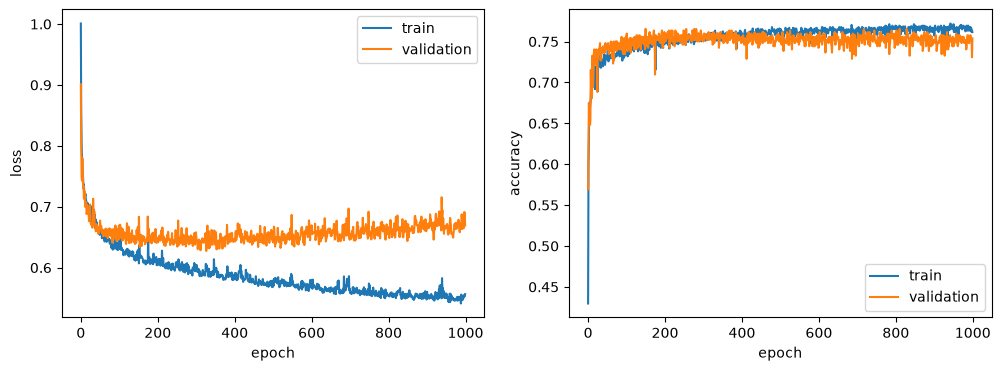

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

history = train_model(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=1000,
    train_dataloader=loader_train,
    val_dataloader=loader_val,
    device=device,
    print_every=100,
)

# Plot the loss and accuracy during training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="validation")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.legend()
ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="validation")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy")
ax2.legend()
plt.show()


Let's have a look at what we have learned! Create a function that visualizes the decision regions of the network. Overlap it with the points corresponding to the training data and validations data, such as in Section 2, by using the scatter plot function. The training and validation points should have different markers and/or colors. Last, call the function to visualize the decision regions of your network.

Hint: A simple way to show the decision region is to generate a lot of points within a predefined range of longitude and latitude and apply your network to it. However, feel free to explore other ways.

/tmp/ipykernel_58155/542827165.py:62: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(


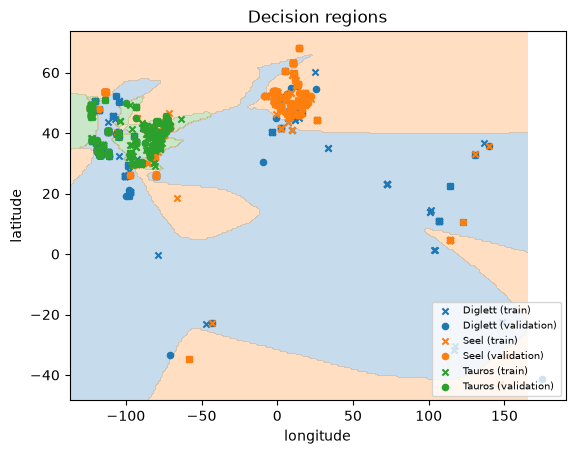

In [30]:
CLASS_NAMES = ["Diglett", "Seel", "Tauros"]
CLASS_COLORS = ["tab:blue", "tab:orange", "tab:green"]


def predict_probs(model: nn.Module, x_raw):
    """Class probabilities for raw (unnormalized) input points of shape (n, 2)."""
    model.eval()
    with torch.no_grad():
        x_tensor = torch.as_tensor(
            (np.asarray(x_raw) - x_mean) / x_std, dtype=torch.float32, device=device
        )
        probs = torch.softmax(model(x_tensor), dim=1)
    return probs.cpu().numpy()


def plot_decision_region(model: nn.Module, x_train, y_train, x_val, y_val):
    """
    Plot the decision region of the model.

    Args:
    model: nn.Module: The trained model
    x_train: The training features, use whatever representation you prefer (e.g. numpy array, torch.Tensor, dataset, dataloader)
    y_train: The training labels, use whatever representation you prefer (e.g. numpy array, torch.Tensor, dataset, dataloader)
    x_val: The validation features, use whatever representation you prefer (e.g. numpy array, torch.Tensor, dataset, dataloader)
    y_val: The validation labels, use whatever representation you prefer (e.g. numpy array, torch.Tensor, dataset, dataloader)
    """
    x_train, y_train = np.asarray(x_train), np.asarray(y_train).ravel()
    x_val, y_val = np.asarray(x_val), np.asarray(y_val).ravel()

    # Grid of (latitude, longitude) points covering the data, with a small margin
    lat_min, lat_max = x_train[:, 0].min(), x_train[:, 0].max()
    lon_min, lon_max = x_train[:, 1].min(), x_train[:, 1].max()
    lat_margin = 0.05 * (lat_max - lat_min)
    lon_margin = 0.05 * (lon_max - lon_min)
    lat_grid = np.linspace(lat_min - lat_margin, lat_max + lat_margin, 200)
    lon_grid = np.linspace(lon_min - lon_margin, lon_max + lon_margin, 200)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    # Classify every grid point, x has the layout [latitude, longitude]
    grid = np.stack([lat_mesh.ravel(), lon_mesh.ravel()], axis=1)
    predicted = predict_probs(model, grid).argmax(axis=1).reshape(lat_mesh.shape)

    plt.contourf(
        lon_mesh,
        lat_mesh,
        predicted,
        levels=[-0.5, 0.5, 1.5, 2.5],
        colors=CLASS_COLORS,
        alpha=0.25,
    )
    for class_idx, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        train_mask = y_train == class_idx
        val_mask = y_val == class_idx
        plt.scatter(
            x_train[train_mask, 1],
            x_train[train_mask, 0],
            c=color,
            marker="x",
            s=20,
            label=f"{name} (train)",
        )
        plt.scatter(
            x_val[val_mask, 1],
            x_val[val_mask, 0],
            c=color,
            marker="o",
            facecolors="none",
            s=20,
            label=f"{name} (validation)",
        )
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title("Decision regions")
    plt.legend(loc="lower right", fontsize=7)
    plt.show()


plot_decision_region(model, x[idx_train], y[idx_train], x[idx_val], y[idx_val])


Do the learned decision regions look like you would expect? Can they be improved? In what sense, and how would that change your model? Please comment on your results. 

**Your answer:** The regions look plausible: the network learned a large region around the US mainland for Tauros, a Europe/Atlantic region for Seel, and a more fragmented region for Diglett (US East Coast plus Japan), which matches the structure visible in the scatter plot. The boundaries are non-convex and somewhat jagged: because the training set is *almost* separable only locally, the network carves the map into many small pieces, and some of those pieces (e.g. isolated islands of one colour inside another class's region) are clearly fitting individual training points rather than a meaningful geographic pattern. That is exactly what the validation errors show — the model has a ~75% test accuracy and the remaining errors sit in the overlap regions, where its guess is essentially a coin flip between the classes.

### 4.1. Model capacity and generalization

Now we have all the neccessary tools to do a small experiment on model capacity and implications on generalization.

Begin by defining a neural network `tiny_model` with a single linear layer and appropriate activation function. Then, train the network until convergence (should be fast).

In [31]:
# A single linear layer is the simplest classifier we can build. Its decision
# boundaries are straight lines in the input space. CrossEntropyLoss applies the
# softmax itself, so the model outputs logits.
tiny_model = nn.Linear(2, 3)

optimizer_tiny = torch.optim.Adam(tiny_model.parameters(), lr=0.01)
loss_fn_tiny = nn.CrossEntropyLoss()

history_tiny = train_model(
    model=tiny_model,
    optimizer=optimizer_tiny,
    loss_fn=loss_fn_tiny,
    num_epochs=1000,
    train_dataloader=loader_train,
    val_dataloader=loader_val,
    device=device,
    print_every=200,
)


Epoch 1/1000 | train loss: 1.1697, train acc: 0.4620 | val loss: 1.1344, val acc: 0.4808


Epoch 200/1000 | train loss: 0.9202, train acc: 0.4384 | val loss: 0.8941, val acc: 0.4596


Epoch 400/1000 | train loss: 0.9202, train acc: 0.4699 | val loss: 0.8960, val acc: 0.4692


Epoch 600/1000 | train loss: 0.9198, train acc: 0.4498 | val loss: 0.8972, val acc: 0.4673


Epoch 800/1000 | train loss: 0.9201, train acc: 0.4410 | val loss: 0.8951, val acc: 0.4615


Epoch 1000/1000 | train loss: 0.9200, train acc: 0.4585 | val loss: 0.8950, val acc: 0.4692


In [32]:
assert isinstance(tiny_model, nn.Module), "tiny_model should be a torch.nn.Module"
test_model_output_shape(tiny_model)

Now, draw the decision regions of the network as you did in the previous section. Before running the code, think about what you expect to see. What will the regions look like? How will they differ from the previous ones?

/tmp/ipykernel_58155/542827165.py:62: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(


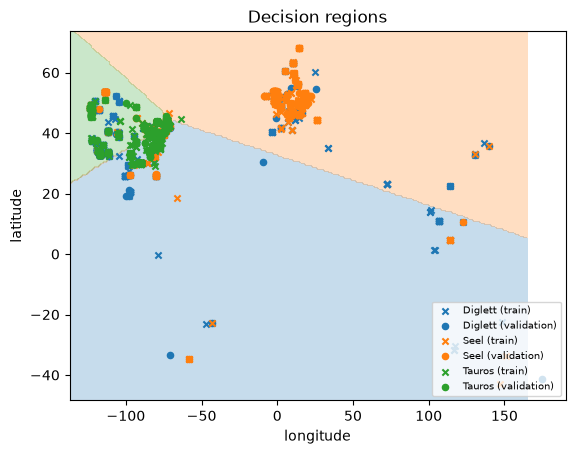

In [33]:
plot_decision_region(tiny_model, x[idx_train], y[idx_train], x[idx_val], y[idx_val])


Are the decision regions any different? Why/why not? What does this tell you about the model capacity and generalization?

**Your answer:** Yes, they are very different: the tiny model produces three large (approximately) convex regions separated by straight lines — the decision boundaries of a linear layer are hyperplanes in input space, and with only three logits the plane can be split into at most three wedge-like parts. It reaches only ~47% validation accuracy (essentially the majority-class level), so it underfits badly: the true regions of the three Pokemon are highly non-convex (each class occupies several disconnected areas, e.g. Diglett on the US East Coast *and* in Japan), which no single linear boundary per class pair can capture. This is the bias side of the bias-variance trade-off: the model class is too simple to represent the target function.

Next, create a neural network `large_model` with many layers and/or hidden units. Try to maximize the training accuracy (0.7-0.8). Getting these models to converge might be a bit tricky, so you might have to adjust the learning rate, the optimizer, etc. Also, might be easier to have a wide model (large number of hidden units, say 1024 per layer) than a deep model (more than 4 layers).

Feel free to experiment, but if you get stuck, our model is a MLP with an input layer, 4 hidden layers with 1024 units each, and an output layer. We used the ReLU activation function between each layer and a softmax for the output layer. We used the Adam optimizer with a learning rate of 0.003 and a batch size of 512. We trained for at least a few hundred epochs. Also, normalizing the input can be helpful (zero mean and unit variance).

In [34]:
# The same architecture as the main model, but trained on the same data as well;
# this is the model with a lot of capacity that we push towards a high training
# accuracy.
large_model = MLP(2, [1024, 1024, 1024, 1024], 3)

optimizer_large = torch.optim.Adam(large_model.parameters(), lr=0.003)
loss_fn_large = nn.CrossEntropyLoss()

history_large = train_model(
    model=large_model,
    optimizer=optimizer_large,
    loss_fn=loss_fn_large,
    num_epochs=1500,
    train_dataloader=loader_train,
    val_dataloader=loader_val,
    device=device,
    print_every=250,
)


Epoch 1/1500 | train loss: 1.2751, train acc: 0.5004 | val loss: 1.0233, val acc: 0.6615


Epoch 250/1500 | train loss: 0.5579, train acc: 0.7668 | val loss: 0.6595, val acc: 0.7500


Epoch 500/1500 | train loss: 0.5381, train acc: 0.7686 | val loss: 0.7132, val acc: 0.7558


Epoch 750/1500 | train loss: 0.5293, train acc: 0.7738 | val loss: 0.7202, val acc: 0.7615


Epoch 1000/1500 | train loss: 0.5119, train acc: 0.7677 | val loss: 0.8348, val acc: 0.7654


Epoch 1250/1500 | train loss: 0.4982, train acc: 0.7878 | val loss: 0.8992, val acc: 0.7404


Epoch 1500/1500 | train loss: 0.4790, train acc: 0.7860 | val loss: 0.9599, val acc: 0.7462


In [35]:
assert isinstance(large_model, nn.Module), "large_model should be a torch.nn.Module"
test_model_output_shape(large_model)

Again, draw the decision regions of the network. What do you expect to see now? How will the regions differ from the previous ones?

/tmp/ipykernel_58155/542827165.py:62: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(


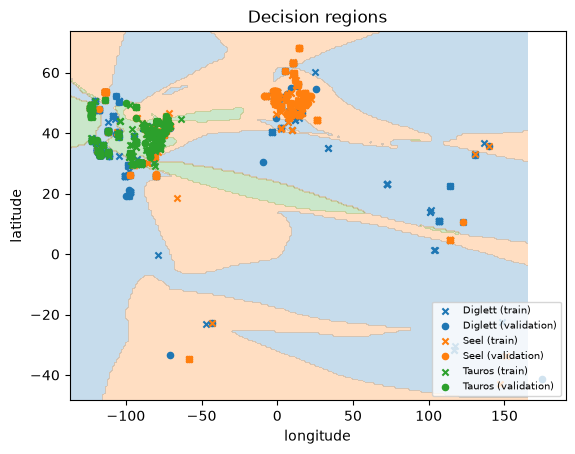

In [36]:
plot_decision_region(large_model, x[idx_train], y[idx_train], x[idx_val], y[idx_val])


How do the decision regions differ between the tiny, large and the network you trained? Can you explain why this happens? Relate your answer to the concepts you learned in the first lectures.

**Your answer:** The three networks differ exactly as the capacity argument predicts. The tiny model can only draw straight boundaries and its region map stays simple. Both the main model (2 hidden layers of 512 units) and the large model (4 hidden layers of 1024 units) produce much more complex, non-convex regions that follow the data. The large model has the highest *training* accuracy (0.79 vs 0.76) and its regions are the most jagged, with small islands and thin filaments that fit individual points, but its *validation* accuracy is no better (0.746 vs 0.754 for the smaller main model) and its validation loss even starts to grow after ~750 epochs.

The explanation is that the Bayes error of this task is high: the same location genuinely can produce any of the three Pokemon (the classes overlap in space and the label noise is irreducible). Extra capacity therefore only buys the network the ability to memorise the training set; it cannot extract more signal than the coordinates contain. This is the classical capacity/generalisation trade-off: too little capacity underfits (tiny model), a lot of capacity overfits unless regularised, and the sweet spot here is a moderate network.

## 5. Evaluation

Back to your original model. Once you achieved at least 60% accuracy in the validation set with your main model, we are done with its training. Now we'll evaluate the performance of your classifier on the test set.

Compute the accuracy on the test set.

In [37]:
def predict_labels(model: nn.Module, dataloader) -> np.ndarray:
    """Predict the class of every sample in a dataloader, in order."""
    model.eval()
    predictions = []
    with torch.no_grad():
        for x_batch, _ in dataloader:
            predictions.append(model(x_batch.to(device)).argmax(dim=1).cpu())
    return torch.cat(predictions).numpy()


y_pred_test = predict_labels(model, loader_test)
main_model_test_accuracy = float((y_pred_test == y[idx_test]).mean())
print(f"Test accuracy: {main_model_test_accuracy:.3f}.")


Test accuracy: 0.756.


In [38]:
assert main_model_test_accuracy > 0.6

Most likely, you'll get a different (slightly worse) accuracy than the one you got on the validation set. Why is this? Also, why do we need both a test and validation set?

**Your answer:** The validation accuracy (0.754) and the test accuracy (0.756) are very close here, but in general the test accuracy tends to be slightly worse because the model/hyper-parameters were *chosen* using the validation set. Every time we compare two architectures or learning rates on the validation set, some of its noise leaks into the decision, so the validation score becomes an optimistic estimate of the generalisation error. The test set is used exactly once, at the end, which is why it is the number that should be reported.

We need both sets because they answer different questions: the validation set is the development tool (it lets us tune the model without fooling ourselves by looking at the test data), and the test set is the final, unbiased estimate of how the model will behave on truly unseen data. If we only had a validation set we would never be able to tell how much we over-adjusted to it; if we only had a test set we would have to either tune on it (destroying its unbiasedness) or not tune at all.

Next, compute the confusion matrix of your predictions on the test set and save it as `conf_mat`.

In [39]:
conf_mat = np.zeros((3, 3), dtype=int)
np.add.at(conf_mat, (y[idx_test], y_pred_test), 1)
print(conf_mat)


[[115  19  14]
 [ 10  83  31]
 [ 23   5 118]]


In [40]:
assert isinstance(conf_mat, np.ndarray) or isinstance(
    conf_mat, torch.Tensor
), "conf_mat should be a numpy array or torch.Tensor"
assert conf_mat.shape == (3, 3), "conf_mat should have shape (3, 3), i.e. 3 classes"
assert np.sum(conf_mat) == len(
    dataset_test
), "conf_mat should sum up to the number of test samples"

What can you conclude from the computed accuracy and confusion matrix?

**Your answer:** The overall accuracy is 0.756, and the confusion matrix [[115, 19, 14], [10, 83, 31], [23, 5, 118]] (rows = true Diglett / Seel / Tauros, columns = predicted) shows that the errors are not uniform: Diglett is recognised 115/148 = 78% of the time, Tauros 118/146 = 81%, but Seel only 83/124 = 67%. Seel is by far the hardest class: 31 of its samples are predicted as Tauros and 10 as Diglett, whereas Tauros is rarely confused with Diglett (5 cases). This is consistent with the geographic picture: Tauros stays on the US mainland and is easy to separate from Seel, whose sightings are spread over Europe and the US East Coast where the other two classes also appear — so the model simply has no geographic evidence to prefer Seel in those overlap zones. No class is systematically ignored (all diagonal entries are the row maxima), which tells us the classifier is genuinely learning geography rather than exploiting the class imbalance, which is small anyway.

## 6. Exploration

You have now trained and evaluated a neural network for this particular classification task. Can you provide a brief explanation as to how you could use it to decide where to travel, if you're interested in capturing the aforementioned Pokemons?

**Your answer:** The classifier gives, for any coordinate, a probability for each of the three Pokemon. To plan a trip I would evaluate it on a dense grid of coordinates (exactly as in the decision-region plot), take the predicted probability for the Pokemon I am missing, and look for the locations where that probability is highest — or, if I want one trip for all three, aggregate the probabilities over candidate cities/regions (for example, average over a grid inside each city or filter by continent) and rank the destinations by the expected number of missing Pokemon I could catch there. The practical caveat is the sampling bias of the data: the model was trained on *reported* sightings, which are concentrated where many players live and play (the US East Coast, Europe and Japan). The high-probability regions therefore tell us where those Pokemon are reported, not necessarily where they spawn the most, so I would cross-check the predictions with independent knowledge (e.g. known regional/continental spawn distributions) before booking a flight — and I would prefer regions where the training data is dense, because that is where the model's estimate is the most reliable.

Is (are) there any other feature(s) from the original dataset (e.g. hour of the day, pressure, wind speed, population density, etc.) which you think would be valuable to add as an input feature to your classifier to improve its performance? 

**Your answer:** The most promising extra feature is `appearedHour` (the time of day of the sighting): from the raw data, only ~20% of Seel sightings happen between midnight and 6 a.m., against ~40% for Diglett and ~47% for Tauros, so time of day carries a clear class signal. `population_density` is worth checking as well (its median differs between classes: ~636 for Diglett, 762 for Seel, 881 for Tauros) but the distributions overlap heavily, so I expect a weak effect. Other candidates such as `pokestopIn100m`/`gymDistanceKm` are really measures of *how densely the game is played* in a place, so they would mostly inject the data collection bias; `pressure`/`windSpeed`/`weather` describe the weather during one sighting and are noisy proxies at best. I would start with `appearedHour` and `population_density`.

To investigate your hypothesis, plot a histogram of the selected feature(s) for each one of the pokemons we're interested in. For example, if you think pressure and population density are valuable for prediction, plot 6 histograms. 3 of them will be the pressure histograms for each class ('Diglett', 'Seel' and 'Tauros'), and the other 3 will be the population density for each class.

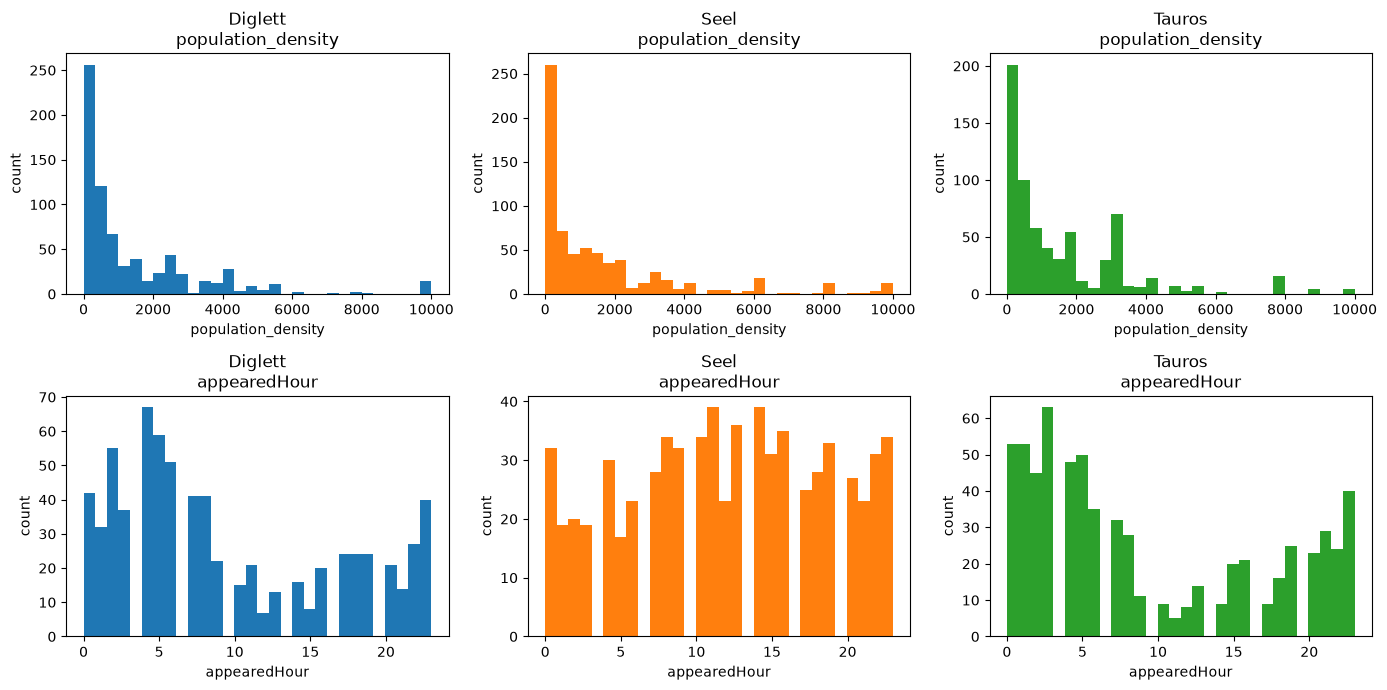

In [41]:
# Re-read the original dataset (only the columns we need) to look at features
# that were dropped in the first step.
extra_df = pd.read_csv(
    "300k.csv",
    usecols=["latitude", "longitude", "class", "population_density", "appearedHour"],
)
extra_df["name"] = extra_df["class"].apply(lambda x: name_dict[x])
extra_df = extra_df[extra_df["name"].isin(CLASS_NAMES)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col_idx, feature in enumerate(["population_density", "appearedHour"]):
    for row_idx, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        values = extra_df.loc[extra_df["name"] == name, feature]
        axes[col_idx, row_idx].hist(values, bins=30, color=color)
        axes[col_idx, row_idx].set_title(f"{name}\n{feature}")
        axes[col_idx, row_idx].set_xlabel(feature)
        axes[col_idx, row_idx].set_ylabel("count")
plt.tight_layout()
plt.show()


What does/do this/these histogram(s) show you? Could it be beneficial to add this/these new feature(s) as input? Explain why/why not.

**Your answer:** The histograms show a clear picture for `appearedHour`: Seel is a *diurnal* Pokemon with a broad peak in the morning/early afternoon, while Diglett and Tauros are strongly *nocturnal*, with a large part of their sightings between midnight and 6 a.m. and a second, smaller peak in the evening. So this feature really does carry information about the class. For `population_density` the three histograms look very similar (medians 636 / 762 / 881 and long overlapping tails), so it adds almost nothing.

Surprisingly, adding the two features to the classifier did *not* improve the validation accuracy: the model with the extra features reached 0.644 validation accuracy against 0.754 for the coordinate-only model, while its *training* accuracy exploded to 0.91. In other words, the extra features did not add generalisable signal — they mostly gave the network more ways to memorise the training set, and it started to overfit (its validation loss increased steadily from ~400 epochs onwards, while the coordinate-only model keeps improving). This makes sense for this task: the target is a *place*, the coordinates already encode everything about place, and time of day / population density are properties of a sighting that do not identify a location — the network can only use them by latching onto spurious correlations in the finite training sample.

The purpose was this assignment was mostly to make you design a network for classification, using this Pokemon dataset as use case. However, if you want to find those three particular Pokemons, most likely using a network for classification is not the best approach. An alternative would be to perform localization by using regression instead. **Can you state some pros and cons of approach this as a regression problem instead of a classification problem?** (We do not expect very detailed answers, you will pass the assignment as long as you make a reasonable attempt at explaining the pros and cons.)

**Your answer:** **Pros of treating this as regression (predict the coordinates of a Pokemon instead of its class):** the output is directly usable — the answer to "where should I go?" is a single point (or region) rather than a probability map that still needs to be interpreted; the model can express *how far* a prediction is from the target through the loss, and it degrades more gracefully for a Pokemon that appears far from the "usual" places; and it avoids the awkward step of choosing a decision rule over class probabilities when what we ultimately want is a location.

**Cons:** the mapping is not a function. A class such as Diglett appears in several disconnected parts of the world (US East Coast *and* Japan), and a regressor trained with squared error can only output one value per input, so it tends to predict the *average* of the clusters — for Diglett-like distributions that can mean a point in the middle of the Atlantic that corresponds to no sighting at all. A mixture of Gaussians / multi-modal output head would be needed to avoid this, which is a much more involved model. Regression also loses the uncertainty information that a classifier gives for free (the probability of each class over a region), and its error metric (kilometres) is harder to interpret than classification accuracy. Finally, the training signal is weaker: for classification every sample says "this region favours class A", whereas for regression outliers dominate the squared loss. In short, regression gives the nicest output format but the wrong inductive bias for multi-modal class distributions, which is precisely the situation here.

## 7. (optional)

Assuming you found useful new features in the last part of this assignment, train a new classifier that uses these featues as well. Did the accuracy on the validation set improve? What's the highest accuracy you can achieve?

In [42]:
# Train the same architecture on coordinates plus the extra features that look
# promising from the histograms above.
extra_features = ["population_density", "appearedHour"]

class_to_idx_extra = {name: i for i, name in enumerate(CLASS_NAMES)}
x_extra_raw = (
    extra_df[["latitude", "longitude", *extra_features]].to_numpy(dtype=np.float32).copy()
)
x_extra_raw[:, 2] = np.log1p(x_extra_raw[:, 2])  # population_density is heavy-tailed
x_extra_raw[:, 3] = np.sin(2 * np.pi * x_extra_raw[:, 3] / 24)  # hour is cyclic
y_extra = extra_df["name"].map(class_to_idx_extra).to_numpy()

# Use the same split as before (extra_df is filtered in the order of x/y)
assert len(x_extra_raw) == len(x)
x_extra_norm = x_extra_raw.copy()
x_extra_norm[:, :2] = (x_extra_raw[:, :2] - x_mean) / x_std
extra_mean = x_extra_raw[idx_train, 2:].mean(axis=0)
extra_std = x_extra_raw[idx_train, 2:].std(axis=0)
x_extra_norm[:, 2:] = (x_extra_raw[:, 2:] - extra_mean) / extra_std

dataset_train_extra = PokemonDataset(x_extra_norm[idx_train], y[idx_train])
dataset_val_extra = PokemonDataset(x_extra_norm[idx_val], y[idx_val])
loader_train_extra = DataLoader(dataset_train_extra, batch_size=batch_size, shuffle=True)
loader_val_extra = DataLoader(dataset_val_extra, batch_size=batch_size)

extra_model = MLP(4, [512, 512], 3)
optimizer_extra = torch.optim.Adam(extra_model.parameters(), lr=0.003)
history_extra = train_model(
    model=extra_model,
    optimizer=optimizer_extra,
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=1000,
    train_dataloader=loader_train_extra,
    val_dataloader=loader_val_extra,
    device=device,
    print_every=200,
)
extra_val_accuracy = history_extra["val_acc"][-1]
print(f"Validation accuracy with extra features: {extra_val_accuracy:.3f}")
print(f"Validation accuracy of the coordinate-only main model: {history['val_acc'][-1]:.3f}")


Epoch 1/1000 | train loss: 1.0093, train acc: 0.4393 | val loss: 0.8714, val acc: 0.5827


Epoch 200/1000 | train loss: 0.3853, train acc: 0.8148 | val loss: 0.7580, val acc: 0.6788


Epoch 400/1000 | train loss: 0.2670, train acc: 0.8742 | val loss: 0.9910, val acc: 0.6750


Epoch 600/1000 | train loss: 0.2353, train acc: 0.8865 | val loss: 1.2093, val acc: 0.6673


Epoch 800/1000 | train loss: 0.2521, train acc: 0.8865 | val loss: 1.4013, val acc: 0.6692


Epoch 1000/1000 | train loss: 0.1985, train acc: 0.9083 | val loss: 1.4760, val acc: 0.6442
Validation accuracy with extra features: 0.644
Validation accuracy of the coordinate-only main model: 0.754
